In [1]:
from social_navigation.mcts.decoupled_mcts import MCTSConfig
from social_navigation.simulator.mcts_game_state import MCTSGameState, MCTSGameStateConfig
import numpy as np
from social_navigation.simulator.scenario_map import ScenarioMap

MAX_ROBOT_SPEED = 2.1
MAX_ROBOT_OMEGA = 2.6
robot_speed = MAX_ROBOT_SPEED * 0.9 # intentionally slow down>?
robot_omega = MAX_ROBOT_OMEGA * 0.9 # 

mcts_config = MCTSConfig(
    num_actors=2, 
    rng=np.random.default_rng(), # better generator
    max_actions=[32, 1],
    max_depth=6,
    c_puct=1.4 * 2.0,
    pw_c=2.0,
    pw_alpha=0.3
)

state_config = MCTSGameStateConfig(
    mcts_config=mcts_config,
    robot_speed=robot_speed,
    dt=0.5,
    robot_radius=1.0,
    human_radius=1.0,
    robot_angular_velocity=robot_omega,
    uncomfortable_distance=1.75,
    starting_distances=np.array([1.0, 1.0]),
    map=ScenarioMap.build_empty(),
)

game_state = MCTSGameState(
    positions=np.zeros((2, 2)),
    velocities=np.zeros((2, 2)),
    agent_goal_positions=np.array([[1.0, 0.0], [1.0, 0.0]]),
    accumulated_value=None,
    config=state_config,
    depth=0
)

In [10]:
positions = []
velocities = []
actions = []

for i in range(8):
    action = game_state.sample_action(0, mcts_config.rng, actions)
    next_state = game_state.apply_actions([action])
    positions.append(next_state.positions[0])
    velocities.append(next_state.velocities[0])
    actions.append(action)

positions = np.array(positions)
velocities = np.array(velocities)

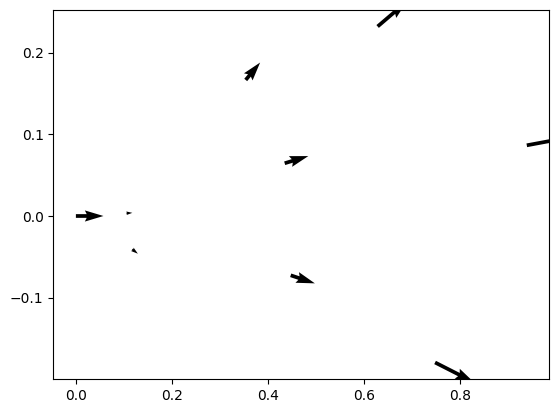

In [11]:
import matplotlib.pyplot as plt

plt.quiver(0, 0, 1, 0)
plt.quiver(positions[:, 0], positions[:, 1], velocities[:, 0], velocities[:, 1])